# 13 - Literature Anchor: The Classifier Ensemble of the Dataset Paper (Vergara et al., 2012)

**Why this notebook exists.** Our project cites Vergara et al. (2012), the paper that introduced this dataset and claimed that an **ensemble of classifiers trained at different points in time** compensates sensor drift
better than baseline methods. Until now we never tested that idea inside our leakage-safe framework. Here we do.

> **Beginner note - the idea of the ensemble.** Train **one SVM per batch** (each one is an "expert" of its own period). To classify a new batch, let all experts vote, but give each expert a **weight** that reflects how well it
> performed on the **most recent labelled batch** (experts that still work on recent data count more).

**Caveat.** As described in secondary literature, not from the original paper itself (we did not access its full text); the details of our version are therefore a re-implementation *in the same spirit*, not an exact copy.

**Declared before running (for test batch k, rolling protocol P3):**
* experts: one default-setting SVM per batch 1 .. k-2 (features standardised with a scaler fitted on those batches);
* weights: each expert's **accuracy on batch k-1**, the most recent labelled batch (ablation: **equal weights**);
* prediction: weighted vote; k = 2 uses a single expert trained on batch 1;
* references: an SVM trained on **the most recent batch only** (a single-period baseline of the kind the ensemble is meant to beat) and an SVM **retrained on all older batches** (our baseline from earlier notebooks);
* hypothesis: the ensemble beats the single most-recent-batch SVM (as claimed in the paper) **but not** full retraining (we saw that more history beats fresher history in notebook 08).
Intervals and verdicts follow notebook 10 (paired two-level bootstrap, 2,000 replicates).

In [1]:
import os, sys, warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "16"); warnings.filterwarnings("ignore")
from pathlib import Path
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.data import load_all
from src.stats import per_batch_f1, bootstrap_f1, compare
from src.plotting import apply_style, INK, INK2, GRID, SERIES, MARKERS
apply_style()
FIG = ROOT / "results" / "figures"; RES = ROOT / "results"
X, y, batch = load_all(); m = batch >= 2; yt, bt = y[m], batch[m]; B = list(range(2, 11))
old = pd.read_csv(RES / "10_predictions_P3.csv"); new = pd.read_csv(RES / "13_predictions_P3.csv")
K = {"single SVM, most recent batch only": old["P3|SVM|raw|window-1"], "ensemble, equal weights": new["P3|SVM|raw|ensemble-equal"],
     "ensemble, accuracy weights (Vergara-style)": new["P3|SVM|raw|ensemble-accuracy"], "single SVM, retrained on all history": old["P3|SVM|raw|baseline"]}
P = {k: v.to_numpy() for k, v in K.items()}
def f1b(k): return per_batch_f1(yt, P[k], bt, B)
def accb(k): return np.array([(P[k][bt == b] == yt[bt == b]).mean() for b in B])

## 0. Validation

For test batch 2 only batch 1 exists, so the ensemble is one SVM trained on batch 1, and the "most recent batch only" reference is also an SVM trained on batch 1. Their predictions must be identical.

In [2]:
a = P["ensemble, accuracy weights (Vergara-style)"][bt == 2]; b_ = P["single SVM, most recent batch only"][bt == 2]; c = P["ensemble, equal weights"][bt == 2]
print("batch 2: ensemble (accuracy) == single SVM on batch 1:", bool((a == b_).all()), "| ensemble (equal) == single SVM:", bool((c == b_).all()))

batch 2: ensemble (accuracy) == single SVM on batch 1: True | ensemble (equal) == single SVM: True


## 1. Results under rolling retraining (P3)

Mean over test batches 2-10 and over batches 4-10 (so that all methods use at least two experts or two training batches).

,macro-F1 (B2-10),macro-F1 (B4-10),accuracy (B2-10),accuracy (B4-10)
"single SVM, most recent batch only",0.652,0.619,0.699,0.661
"ensemble, equal weights",0.525,0.532,0.597,0.589
"ensemble, accuracy weights (Vergara-style)",0.625,0.660,0.674,0.687
"single SVM, retrained on all history",0.797,0.809,0.824,0.825


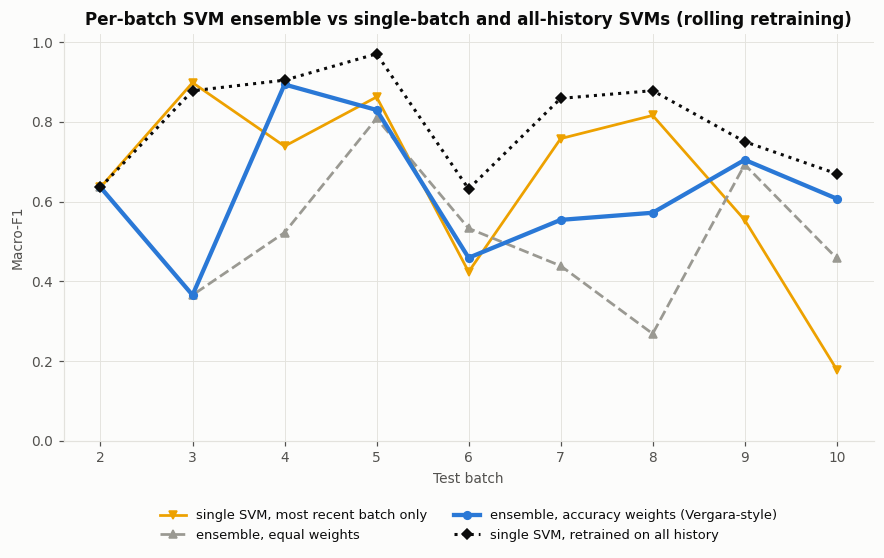

In [3]:
tab = pd.DataFrame({k: {"macro-F1 (B2-10)": f1b(k).mean(), "macro-F1 (B4-10)": f1b(k)[2:].mean(), "accuracy (B2-10)": accb(k).mean(), "accuracy (B4-10)": accb(k)[2:].mean()} for k in P}).T
tab.to_csv(RES / "13_summary_P3.csv"); display(tab.round(3))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
sty = {"single SVM, most recent batch only": (SERIES[3], "-", "v", 1.8), "ensemble, equal weights": ("#9a9992", "--", "^", 1.8),
       "ensemble, accuracy weights (Vergara-style)": (SERIES[0], "-", "o", 2.8), "single SVM, retrained on all history": (INK, ":", "D", 2.0)}
for k, (c, ls, mk, lw) in sty.items(): ax.plot(B, f1b(k), color=c, ls=ls, marker=mk, ms=5, lw=lw, label=k)
ax.set_xlabel("Test batch"); ax.set_ylabel("Macro-F1"); ax.set_ylim(0, 1.02); ax.set_xticks(B); ax.set_title("Per-batch SVM ensemble vs single-batch and all-history SVMs (rolling retraining)")
ax.legend(frameon=False, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2); fig.savefig(FIG / "46_vergara_ensemble_per_batch.png"); plt.show()

## 2. Declared comparisons with confidence intervals

Difference in mean macro-F1 over test batches 2-10 (A minus B), paired two-level bootstrap; `A>B` = number of the 9 test batches on which A is better.

In [4]:
F, names = bootstrap_f1(yt, P, bt, B, n_boot=2000, seed=42); point = {k: f1b(k) for k in P}
pairs = [("ensemble, accuracy weights (Vergara-style)", "single SVM, most recent batch only", "ensemble vs single SVM on the most recent batch"),
         ("ensemble, accuracy weights (Vergara-style)", "single SVM, retrained on all history", "ensemble vs SVM retrained on all history"),
         ("ensemble, accuracy weights (Vergara-style)", "ensemble, equal weights", "accuracy weights vs equal weights"),
         ("ensemble, equal weights", "single SVM, most recent batch only", "equal-weight ensemble vs single SVM on the most recent batch")]
rows = []
for a, b_, label in pairs:
    r = compare(F, names, a, b_, point)
    rows.append({"comparison": label, "diff": r["diff"], "ci2_lo": r["ci_two_level"][0], "ci2_hi": r["ci_two_level"][1], "A>B": f"{r['batches_A_better']}/{r['n_batches']}", "p": r["wilcoxon_p"], "verdict": r["verdict"]})
cmp_ = pd.DataFrame(rows); cmp_.to_csv(RES / "13_comparisons.csv", index=False); display(cmp_.round(3))

,comparison,diff,ci2_lo,ci2_hi,A>B,p,verdict
0,ensemble vs single SVM on the most recent batch,-0.027,-0.201,0.141,4/9,0.844,suggestive
1,ensemble vs SVM retrained on all history,-0.173,-0.281,-0.073,0/9,0.008,clear
2,accuracy weights vs equal weights,0.100,0.015,0.201,6/9,0.078,clear
3,equal-weight ensemble vs single SVM on the mos...,-0.127,-0.316,0.041,3/9,0.312,suggestive


### Exploratory (post hoc, not declared): only test batches 4-10

For test batches 2 and 3 the ensemble has no real ensemble (zero or one expert), so the full-range comparison handicaps it. Restricting to batches 4-10 (at least two experts) was decided **after** seeing the table above;
treat it as a hypothesis, not a finding.

In [5]:
sub = bt >= 4; B4 = list(range(4, 11)); ysub, bsub = yt[sub], bt[sub]; P4_ = {k: v[sub] for k, v in P.items()}
F4, n4 = bootstrap_f1(ysub, P4_, bsub, B4, n_boot=2000, seed=42); pt4 = {k: per_batch_f1(ysub, P4_[k], bsub, B4) for k in P4_}
rows = []
for a, b_, label in pairs[:3]:
    r = compare(F4, n4, a, b_, pt4)
    rows.append({"comparison (exploratory, B4-10)": label, "diff": r["diff"], "ci2_lo": r["ci_two_level"][0], "ci2_hi": r["ci_two_level"][1], "A>B": f"{r['batches_A_better']}/{r['n_batches']}", "verdict": r["verdict"]})
expl = pd.DataFrame(rows); expl.to_csv(RES / "13_comparisons_exploratory_B4-10.csv", index=False); display(expl.round(3))

,"comparison (exploratory, B4-10)",diff,ci2_lo,ci2_hi,A>B,verdict
0,ensemble vs single SVM on the most recent batch,0.041,-0.116,0.210,4/7,suggestive
1,ensemble vs SVM retrained on all history,-0.149,-0.235,-0.068,0/7,clear
2,accuracy weights vs equal weights,0.128,0.020,0.242,6/7,clear


## 3. A "setting 1" view: train on batch 1 only, test on each later batch

The dataset paper evaluates models trained once on an early batch against all later batches. Our protocol P2 is exactly that. Accuracy of the default SVM per test batch (batch 1 as the only training batch):

In [6]:
r04 = pd.read_csv(RES / "04_baselines_results.csv")
s1 = r04[(r04.protocol == "P2") & (r04.variant == "raw") & r04.model.isin(["SVM", "kNN"])].pivot(index="model", columns="test_batch", values="accuracy")
s1["mean"] = s1.mean(axis=1); s1.to_csv(RES / "13_setting1_accuracy.csv"); display(s1.round(3))

test_batch,2,3,4,5,6,7,8,9,10,mean
model,,,,,,,,,,
SVM,0.762,0.494,0.335,0.239,0.337,0.333,0.255,0.343,0.414,0.390
kNN,0.680,0.395,0.342,0.254,0.340,0.313,0.129,0.383,0.448,0.365


## 4. Key takeaways

Default-setting SVMs, rolling retraining (P3). This is a re-implementation in the spirit of Vergara et al. (2012), built from a secondary description of the method, **not** a replication of the paper's reported numbers.

| Method | macro-F1 (B2-10) | accuracy (B2-10) | macro-F1 (B4-10) |
|---|---|---|---|
| Single SVM, most recent batch only | 0.652 | 0.699 | 0.619 |
| Ensemble, equal weights | 0.525 | 0.597 | 0.532 |
| **Ensemble, accuracy weights (Vergara-style)** | 0.625 | 0.674 | 0.660 |
| Single SVM, retrained on all history | **0.797** | **0.824** | **0.809** |

1. **The weighting idea works.** Weighting the per-batch experts by their accuracy on the most recent labelled batch is clearly better than an equal-weight vote: +0.100 macro-F1 (two-level 95% CI +0.015 to +0.201, better on 6 of 9 batches; on batches 4-10 +0.128, +0.020 to +0.242). This is the core mechanism of the dataset paper and it is reproduced here.
2. **Against a single-period baseline the ensemble shows no clear advantage.** Ensemble minus the SVM trained on the most recent batch only: -0.027 (-0.201 to +0.141, better on 4 of 9 batches; suggestive at most). Restricting to test batches 4-10, where the ensemble has at least two experts, the sign flips to +0.041 (-0.116 to +0.210, 4 of 7), but that restriction was chosen after seeing the full-range result, so it is a hypothesis, not a finding. Batches 2 and 3 handicap the ensemble by design: it has zero or one expert there because the most recent labelled batch is reserved for the weights.
3. **Against the simplest strong baseline it clearly loses.** Retraining one SVM on all older batches beats the ensemble by 0.173 macro-F1 (-0.281 to -0.073, worse on all 9 batches; B4-10: -0.149, worse on all 7). Combined with the sliding-window and recency results of notebook 08, the consistent message is that, in this benchmark, **pooling all available labelled history is the strongest simple strategy**; the ensemble idea only helps relative to weaker, single-period baselines.
4. **Why the ensemble may fall short (hypotheses, not tested).** Each expert sees a single, small and differently composed batch (several batches have only 161-470 samples, and gas mixes differ), hard votes discard confidence information, and the freshest batch is used only for weighting.
5. **Setting 1 (train once on batch 1, test on every later batch) for reference.** Accuracy of the default SVM on test batches 2 to 10: 0.762, 0.494, 0.335, 0.239, 0.337, 0.333, 0.255, 0.343, 0.414 (mean 0.390; kNN mean 0.365): about two thirds of the accuracy is lost within three batches, which is exactly the drift problem the dataset paper set out to solve.
6. **Caveats.** The paper's exact protocol, scaling and weight formula were not available to us, so details may differ; default-setting SVMs only; wide intervals from only 9 (or 7) test batches; the declared comparisons were not corrected for multiple testing.